In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd '/content/drive/MyDrive/Classroom/test/hw3'
import sys
sys.path.append('/content/drive/MyDrive/Classroom/test/hw3')

Mounted at /content/drive
/content/drive/MyDrive/Classroom/test/hw3


# Design and Evaluation of a Custom CNN for Fashion-MNIST Image Classification

Fashion MNIST is a dataset consisting of grayscale images of various fashion items. Each image in the dataset is 28×28 pixels in size and contains only grayscale values. The entire dataset comprises 70,000 images, of which 60,000 are used for training and 10,000 are reserved for testing. It includes a total of 10 distinct classes representing different types of clothing and footwear, such as T-shirts/tops, trousers, sneakers, and more.
Fashion MNIST was created as a more challenging alternative to the original MNIST (handwritten digits), which had become too easy for modern models. It is used to test new CNN or model architectures.

In [2]:
import torchvision
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, utils
import numpy as np
import matplotlib.pyplot as plt
import torchvision.models as models

import datetime
import torch.nn.functional as F
from tqdm.notebook import tqdm

import random

In [3]:
# To ensure reproducibility, set seeds for all the libraries that introduce randomness.

SEED = 42

# Set seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior in CUDA (slower but reproducible)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load the FashionMNIST dataset and normalize pixel values.

In [4]:
# train_transform = transforms.Compose([
#     transforms.RandomRotation(10),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

nontrain_transform = transforms.Compose([
    transforms.ToTensor(),                             # Converts to [0,1]
    transforms.Normalize((0.5,), (0.5,)) # Normalize [-1, 1]
])

full_trainset = torchvision.datasets.FashionMNIST(root='./FashionMNIST_data', train=True, download=False, transform=nontrain_transform)


# Review distribution of images in each class.

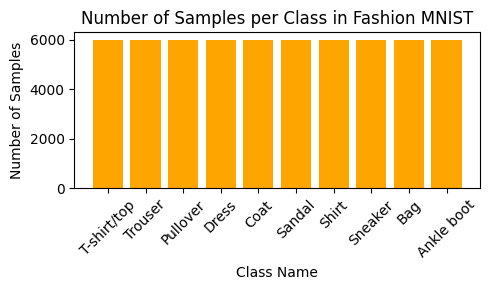

In [5]:
from collections import Counter

targets = full_trainset.targets
classes, counts = torch.unique(targets, return_counts=True)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(5, 3))
plt.bar(class_names, counts, color='orange')
plt.xlabel('Class Name')
plt.ylabel('Number of Samples')
plt.title('Number of Samples per Class in Fashion MNIST')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Reivew images in the FashinMNIST dataset.

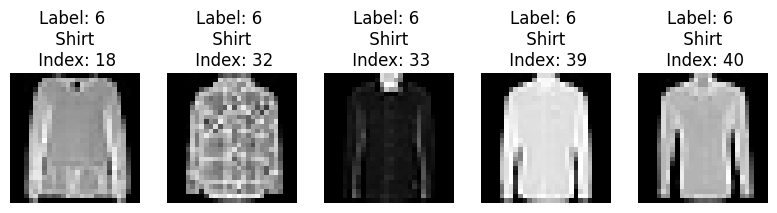

In [6]:
def peek(dataset1):
  label_6_images = []
  num = []

  # Loop to find images with label 6
  for idx, (img, label) in enumerate(full_trainset):
      if label == 6:
          label_6_images.append(img)
          num.append(idx)
      if len(label_6_images) == 5:  # Show only first 5 for example
          break

  # Plot the first 5 images with label 6
  fig, axs = plt.subplots(1, 5, figsize=(8, 2))
  for i in range(5):
      axs[i].imshow(label_6_images[i].squeeze(), cmap='gray')
      axs[i].set_title(f"Label: 6 \n {class_names[label]} \n Index: {num[i]}")
      axs[i].axis('off')

  plt.tight_layout()
  plt.show()

peek(full_trainset)

## Split dataset to training and validation datasets with scale 0.9 using randomsplit.

In [7]:

# class TransformedDataset(torch.utils.data.Dataset):
#     def __init__(self, dataset, transform):
#         self.dataset = dataset
#         self.transform = transform

#     def __getitem__(self, index):
#         img, label = self.dataset[index]
#         img = self.transform(img)
#         return img, label

#     def __len__(self):
#         return len(self.dataset)

from torch.utils.data import random_split

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator().manual_seed(SEED)

train_size = int(0.9 * len(full_trainset))
val_size = len(full_trainset) - train_size

train_dataset, val_dataset = random_split(full_trainset, [train_size, val_size], generator=generator)

print(len(train_dataset), len(val_dataset))

# train_dataset = TransformedDataset(train_dataset, train_transform)
# val_dataset = TransformedDataset(val_dataset, nontrain_transform)

batch_size = 32

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, worker_init_fn=seed_worker,
    generator=generator, pin_memory=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size, num_workers=2, worker_init_fn=seed_worker,
    generator=generator, pin_memory=True)

# Download and load test set
# test_dataset = torchvision.datasets.FashionMNIST(root='./FashionMNIST_data', train=False, download=False, transform=transform)
# test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False)

# print(len(test_dataset))


54000 6000


## Design a Custom CNN model.

In [8]:
device = (torch.device('cuda') if torch.cuda.is_available()
         else torch.device('cpu'))
print(f"Training on device {device}.")

from torchsummary import summary

class CustomCNN(nn.Module):
    def __init__(self, num_classes=10):

        super().__init__()

        # Original Operations

        self.conv1_in = 1
        self.conv1_out = 32
        self.conv1_kernel_size = 3
        self.conv1 = nn.Conv2d(self.conv1_in, self.conv1_out, kernel_size=self.conv1_kernel_size, padding=1)

        self.conv2_in = self.conv1_out
        self.conv2_out = 32
        self.conv2_kernel_size = 3
        self.conv2 = nn.Conv2d(self.conv2_in, self.conv2_out, kernel_size=self.conv2_kernel_size, padding=1)

        self.conv3_in = self.conv2_out
        self.conv3_out = 64
        self.conv3_kernel_size = 3
        self.conv3 = nn.Conv2d(self.conv3_in, self.conv3_out, kernel_size=self.conv3_kernel_size, padding=1)

        self.conv4_in = self.conv3_out
        self.conv4_out = 128
        self.conv4_kernel_size = 3
        self.conv4 = nn.Conv2d(self.conv4_in, self.conv4_out, kernel_size=self.conv4_kernel_size, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

        self.dropout1 = nn.Dropout(0.25)
        # self.dropout1 = nn.Dropout(0.1)
        # self.dropout2 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        self.norm1 = nn.BatchNorm2d(self.conv1_out)
        self.norm2 = nn.BatchNorm2d(self.conv2_out)
        self.norm3 = nn.BatchNorm2d(self.conv3_out)
        self.norm4 = nn.BatchNorm2d(self.conv4_out)

        # Fully Connected Layers
        self.fc1_in_features = self.conv4_out * 7 * 7
        self.fc1_out_features = 128
        self.fc1 = nn.Linear(self.fc1_in_features, self.fc1_out_features)

        self.fc2_in_features = self.fc1_out_features
        self.fc2_out_features = 10
        self.fc2 = nn.Linear(self.fc2_in_features, self.fc2_out_features)

        self.norm1d_1 = nn.BatchNorm1d(self.fc1_out_features)
        self.norm1d_2 = nn.BatchNorm1d(self.fc2_out_features)

        self.flatten = nn.Flatten()

    def forward(self, x):
        # Original Operations
        x = self.conv1(x)
        x = self.norm1(x)
        x = self.relu(x)
        x = self.dropout1(x)
        x = self.conv2(x)
        x = self.norm2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)

        x = self.conv3(x)
        x = self.norm3(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.dropout1(x)

        x = self.conv4(x)
        x = self.norm4(x)
        x = self.relu(x)
        x = self.dropout1(x)

        # Faltten layer
        x = self.flatten(x)

        # Fully Connected Layers
        x = self.fc1(x)
        x = self.norm1d_1(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)

        return x


model = CustomCNN()
print(model)
model = model.to(device)
summary(model, input_size=(1, 28, 28))


Training on device cuda.
CustomCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (norm3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (norm4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6272, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_

## Define the training loop. If the validation accuracy is not changed in 10 epochs, the training is stopped, and the model that gives the highest accuracy is saved and used later for evaluation of the model on test dataset.





In [9]:
import copy

def calculate_accuracy(y_pred, y_true):
    predicted = torch.argmax(y_pred, dim=1)
    correct = (predicted == y_true).sum().item()
    return correct / y_true.size(0)


def training_loop(n_epochs, optimizer, scheduler, model, loss_fn, train_loader, val_loader):
# def training_loop(n_epochs, optimizer, model, loss_fn, train_loader, val_loader):

  train_losses, val_losses = [], []

  train_acc = []

  val_acc = []

  patience = 10
  best_val_acc = 0.0
  counter = 0
  best_epoch = 0

  best_model_wts = model

  for epoch in range(1, n_epochs + 1):
    print(f"--- EPOCH: {epoch} ---")
    loss_train = 0.0
    acc_train = 0.0
    model.train()
    for imgs, labels in train_loader:
    # loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}")
    # for imgs, labels in loop:

      imgs, labels = imgs.to(device=device), labels.to(device=device)

      y_pred = model(imgs)

      loss = loss_fn(y_pred, labels)

      optimizer.zero_grad()

      loss.backward()

      optimizer.step()

      loss_train += loss.item()

      acc_train += calculate_accuracy(y_pred, labels)

    scheduler.step()

    model.eval()
    acc_val = 0.0
    loss_val = 0.0

    for imgs, labels in val_loader:

      imgs, labels = imgs.to(device=device), labels.to(device=device)

      y_val_pred = model(imgs)

      with torch.no_grad():
        loss = loss_fn(y_val_pred, labels)
        loss_val += loss.item()

        acc_val += calculate_accuracy(y_val_pred, labels)

    loss_train_epoch = loss_train / len(train_loader)
    loss_val_epoch = loss_val / len(val_loader)

    acc_train_epoch = acc_train /len(train_loader)

    acc_val_epoch = acc_val /len(val_loader)

    train_losses.append(loss_train_epoch)
    val_losses.append(loss_val_epoch)

    train_acc.append(acc_train_epoch)
    val_acc.append(acc_val_epoch)

    print(f"Epoch {epoch}/{n_epochs}: "
      f"Train Loss: {loss_train_epoch:.4f}, Train Acc: {acc_train_epoch:.4f}, "
      f"Val Loss: {loss_val_epoch:.4f}, Val Acc: {acc_val_epoch:.4f}")

    # Early stopping

    if acc_val_epoch > best_val_acc:
        best_val_acc = acc_val_epoch
        best_epoch = epoch
        best_model_wts = copy.deepcopy(model.state_dict()) # Save best model
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\n\nEarly stopping at epoch {epoch}")
            break

  # Load the best model
  model.load_state_dict(best_model_wts)

  return train_losses, val_losses, train_acc, val_acc, model, best_val_acc, best_epoch


## Define hyperparameters for training. Start the training.


*   Optimizer: Adam
*   Learning Rate: 0.005
*   Scheduler: StepLR (Reduces the learning rate by a factor of 0.1 every 7 epochs)
*   Epochs: 100
*   Loss Function: CrossEntropyLoss


In [10]:
import time

model = CustomCNN()

model = model.to(device)

loss_fn = nn.CrossEntropyLoss()

# optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

optimizer = optim.Adam(model.parameters(), lr=0.005)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

n_epochs = 100

start = time.time()

train_losses, val_losses, train_acc, val_acc, model, best_val_acc, best_epoch = training_loop(
    n_epochs = n_epochs,
    optimizer = optimizer,
    scheduler = scheduler,
    model = model,
    loss_fn = loss_fn,
    train_loader = train_dataloader,
    val_loader = val_dataloader,
)

end = time.time()

print(f"Time taken: {end - start:.4f} seconds")

print(f"Best Epoch {best_epoch}: "
  f"Best Val Acc: {best_val_acc:.4f}")


--- EPOCH: 1 ---
Epoch 1/100: Train Loss: 0.4810, Train Acc: 0.8262, Val Loss: 0.3105, Val Acc: 0.8846
--- EPOCH: 2 ---
Epoch 2/100: Train Loss: 0.3521, Train Acc: 0.8735, Val Loss: 0.2527, Val Acc: 0.9061
--- EPOCH: 3 ---
Epoch 3/100: Train Loss: 0.3162, Train Acc: 0.8859, Val Loss: 0.2293, Val Acc: 0.9126
--- EPOCH: 4 ---
Epoch 4/100: Train Loss: 0.2974, Train Acc: 0.8935, Val Loss: 0.2579, Val Acc: 0.9048
--- EPOCH: 5 ---
Epoch 5/100: Train Loss: 0.2808, Train Acc: 0.8984, Val Loss: 0.2179, Val Acc: 0.9177
--- EPOCH: 6 ---
Epoch 6/100: Train Loss: 0.2660, Train Acc: 0.9040, Val Loss: 0.2197, Val Acc: 0.9200
--- EPOCH: 7 ---
Epoch 7/100: Train Loss: 0.2554, Train Acc: 0.9080, Val Loss: 0.2082, Val Acc: 0.9242
--- EPOCH: 8 ---
Epoch 8/100: Train Loss: 0.2167, Train Acc: 0.9215, Val Loss: 0.1906, Val Acc: 0.9297
--- EPOCH: 9 ---
Epoch 9/100: Train Loss: 0.2084, Train Acc: 0.9252, Val Loss: 0.1828, Val Acc: 0.9340
--- EPOCH: 10 ---
Epoch 10/100: Train Loss: 0.2002, Train Acc: 0.9274, Va

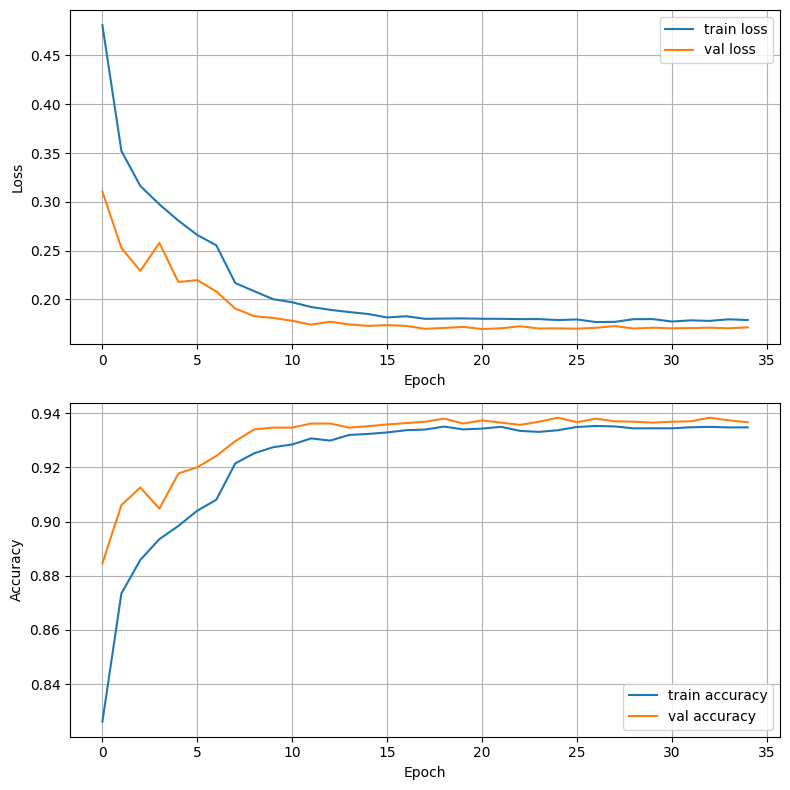

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# Plot losses
ax1.plot(train_losses, label='train loss')
ax1.plot(val_losses, label='val loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot accuracies
ax2.plot(train_acc, label='train accuracy')
ax2.plot(val_acc, label='val accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()



## Load the test Dataset.

In [12]:
# Load test dataset

test_dataset = torchvision.datasets.FashionMNIST(root='./FashionMNIST_data', train=False, download=False, transform=nontrain_transform)
batch_size = 512
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(len(test_dataset))


10000


## Evaluation of the model on the test Dataset. Inference time is checked for efficiency (i.e for production environment).


In [13]:
import time
import sys

total_correct = 0
total_samples = 0
inference_times = []

preds, targets = [], []

model.eval()

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        # Start timing (use CUDA sync if needed)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start_time = time.time()

        y_pred = model(images) #torch.Size([512, 10])

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        end_time = time.time()

        # Record inference time for the batch
        inference_times.append(end_time - start_time)

        # Calculate predictions and accuracy

        _, predicted = torch.max(y_pred, 1) #torch.Size([512])

        preds.extend(predicted.cpu().tolist())
        targets.extend(labels.cpu().tolist())

        total_correct += (predicted == labels).sum().item()
        total_samples += labels.size(0)

# --- Results ---
accuracy = total_correct / total_samples * 100
avg_inference_time = sum(inference_times) / len(inference_times)  # Per batch
avg_time_per_image = avg_inference_time / test_dataloader.batch_size

print(f"✅ Test Accuracy: {accuracy:.2f}%")
print(f"⏱️ Average inference time per batch: {avg_inference_time:.6f} sec")
print(f"⏱️ Average inference time per image: {avg_time_per_image:.6f} sec")


✅ Test Accuracy: 93.47%
⏱️ Average inference time per batch: 0.005496 sec
⏱️ Average inference time per image: 0.000011 sec


## Confusion matrix.

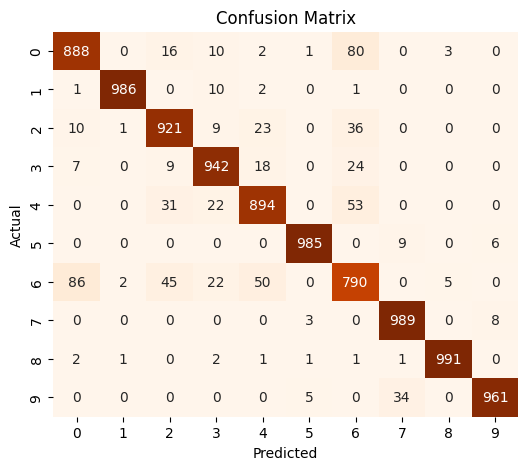

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(targets, preds)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Review images that the model does not predict correctly.

In [15]:
print("Indices where true label is 6 and prediction is incorrect:")

wrong_indices = [i for i, (true, pred) in enumerate(zip(targets, preds)) if true == 6 and pred != 6]

print(wrong_indices)


Indices where true label is 6 and prediction is incorrect:
[147, 244, 444, 548, 565, 628, 634, 711, 909, 921, 938, 966, 977, 1025, 1056, 1058, 1131, 1152, 1162, 1165, 1197, 1210, 1235, 1487, 1496, 1620, 1642, 1643, 1645, 1650, 1771, 1922, 1943, 2162, 2190, 2195, 2311, 2326, 2351, 2352, 2397, 2425, 2469, 2485, 2491, 2500, 2540, 2551, 2580, 2603, 2629, 2661, 2839, 2842, 2843, 2856, 2942, 2985, 2986, 3045, 3174, 3188, 3198, 3232, 3262, 3334, 3338, 3416, 3429, 3488, 3510, 3613, 3625, 3669, 3681, 3741, 3787, 3800, 3829, 3830, 3864, 3987, 4019, 4079, 4106, 4127, 4140, 4142, 4153, 4194, 4231, 4267, 4280, 4542, 4569, 4692, 4727, 4784, 4803, 4817, 4886, 4916, 5006, 5052, 5065, 5155, 5161, 5184, 5186, 5228, 5248, 5249, 5266, 5424, 5521, 5522, 5566, 5569, 5594, 5654, 5695, 5806, 5885, 5977, 5987, 6008, 6024, 6037, 6127, 6160, 6169, 6248, 6254, 6258, 6452, 6539, 6558, 6596, 6626, 6655, 6832, 6844, 6861, 6928, 6958, 7004, 7026, 7042, 7095, 7130, 7167, 7182, 7188, 7189, 7195, 7222, 7258, 7334, 7416,

## Shirts are more likely to be confused with coats, T-shirts, pullover as they look similar in gray scale.

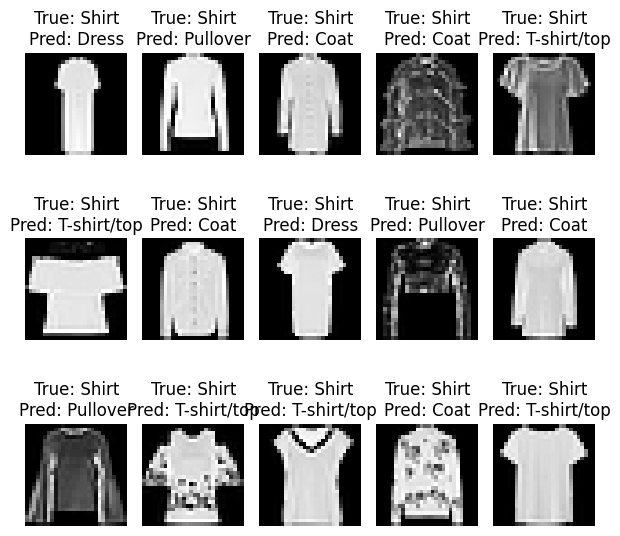

In [16]:
import matplotlib.pyplot as plt

count = 0
fig, axs = plt.subplots(3, 5, figsize=(6, 6))

for i, (true, pred) in enumerate(zip(targets, preds)):
    if true == 6 and pred != 6:
        if count >= 15:
            break

        image, label = test_dataset[i]

        row = count // 5
        col = count % 5

        axs[row][col].imshow(image.squeeze(), cmap='gray')
        axs[row][col].set_title(f"True: {class_names[true]}\nPred: {class_names[pred]}")
        axs[row][col].axis('off')

        count += 1

plt.tight_layout()
plt.show()




## Among 10 classes, items like throusers, shoes, and bags yield better results than clothes like shirts, T-shirt/tops, coats, and pullovers.

In [17]:
from sklearn.metrics import classification_report

y_true = targets.cpu().numpy() if torch.is_tensor(targets) else targets
y_pred = preds.cpu().numpy() if torch.is_tensor(preds) else preds

num_classes = 10
target_names = [f"Class {i}  {class_names[i]}" for i in range(num_classes)]

print(classification_report(y_true, y_pred, target_names=target_names))


                      precision    recall  f1-score   support

Class 0  T-shirt/top       0.89      0.89      0.89      1000
    Class 1  Trouser       1.00      0.99      0.99      1000
   Class 2  Pullover       0.90      0.92      0.91      1000
      Class 3  Dress       0.93      0.94      0.93      1000
       Class 4  Coat       0.90      0.89      0.90      1000
     Class 5  Sandal       0.99      0.98      0.99      1000
      Class 6  Shirt       0.80      0.79      0.80      1000
    Class 7  Sneaker       0.96      0.99      0.97      1000
        Class 8  Bag       0.99      0.99      0.99      1000
 Class 9  Ankle boot       0.99      0.96      0.97      1000

            accuracy                           0.93     10000
           macro avg       0.93      0.93      0.93     10000
        weighted avg       0.93      0.93      0.93     10000

